In [3]:
# 1) Data Cleaning and Preparation
import pandas as pd
import numpy as np
df = pd.read_csv("Cardiotocographic.csv")
df.info()
# Loading of dataset into dataframe and getting information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [4]:
df.isnull().sum()
#Checking for null values in the dataset

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [5]:
skew_values = df.skew()
print(skew_values)
#Checking the skewness of each columns in dataset in order to fill the null values with proper central tendency

LB          0.320747
AC          2.016787
FM          6.753070
UC          0.974239
DL          2.010390
DS          8.418984
DP          6.422466
ASTV        0.055872
MSTV        4.142518
ALTV        2.981199
MLTV        3.541448
Width       0.495246
Tendency   -0.496789
NSP         1.810900
dtype: float64


In [6]:
for col in df.columns:
    print(df[col].apply(type).value_counts())
# In order to check if single column has multiple datatypes the above code is used to detect the same.

LB
<class 'float'>    2126
Name: count, dtype: int64
AC
<class 'float'>    2126
Name: count, dtype: int64
FM
<class 'float'>    2126
Name: count, dtype: int64
UC
<class 'float'>    2126
Name: count, dtype: int64
DL
<class 'float'>    2126
Name: count, dtype: int64
DS
<class 'float'>    2126
Name: count, dtype: int64
DP
<class 'float'>    2126
Name: count, dtype: int64
ASTV
<class 'float'>    2126
Name: count, dtype: int64
MSTV
<class 'float'>    2126
Name: count, dtype: int64
ALTV
<class 'float'>    2126
Name: count, dtype: int64
MLTV
<class 'float'>    2126
Name: count, dtype: int64
Width
<class 'float'>    2126
Name: count, dtype: int64
Tendency
<class 'float'>    2126
Name: count, dtype: int64
NSP
<class 'float'>    2126
Name: count, dtype: int64


In [7]:
import pandas as pd

def detect_outliers_iqr(df):
    outlier_dict = {}
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_dict[col] = outliers[col]
    
    return outlier_dict

outliers_all = detect_outliers_iqr(df)

for col, outliers in outliers_all.items():
    print(f"\nColumn: {col}")
    print(f"Number of outliers: {outliers.shape[0]}")
    print(outliers.head())


Column: LB
Number of outliers: 10
134     52.0
411    214.0
610    214.0
612    214.0
785     52.0
Name: LB, dtype: float64

Column: AC
Number of outliers: 40
8      0.038567
23    -0.019284
83     0.014706
85     0.014230
116    0.038567
Name: AC, dtype: float64

Column: FM
Number of outliers: 347
12    0.072335
13    0.222390
14    0.407840
15    0.380223
16    0.441400
Name: FM, dtype: float64

Column: UC
Number of outliers: 13
134     0.029851
543     0.029851
793    -0.014925
917     0.029851
1164    0.014925
Name: UC, dtype: float64

Column: DL
Number of outliers: 125
5     0.009444
6     0.008415
28    0.008340
29    0.012158
30    0.010008
Name: DL, dtype: float64

Column: DS
Number of outliers: 120
33    -0.000002
38     0.000004
69    -0.000003
84     0.000003
113   -0.000002
Name: DS, dtype: float64

Column: DP
Number of outliers: 284
5     0.002099
6     0.002805
14    0.000826
15    0.001393
17    0.001524
Name: DP, dtype: float64

Column: ASTV
Number of outliers: 10
131 

In [8]:
df[['Width','AC','UC','DS','ASTV','Tendency','NSP']] = df[['Width','AC','UC','DS','ASTV','Tendency','NSP']].mask(df[['Width','AC','UC','DS','ASTV','Tendency','NSP']] < 0, np.nan)
# These all values cannot have negative values and hence should be considered as outliers and treated.

In [14]:
df[['AC','DS','DP','MLTV','NSP']] = df[['AC','DS','DP','MLTV','NSP']].fillna(df[['AC','DS','DP','MLTV','NSP']].median())
# More skewed data is filled with median

In [15]:
df['ASTV'] = df['ASTV'].clip(0, 100)

In [16]:
df[['LB','Width','Tendency']] = df[['LB','Width','Tendency']].fillna(df[['LB','Width','Tendency']].mean())
#Less skewed data is filled with mean

In [17]:
import pandas as pd

def detect_outliers_iqr(df):
    outlier_dict = {}
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_dict[col] = outliers[col]
    
    return outlier_dict

outliers_all = detect_outliers_iqr(df)

for col, outliers in outliers_all.items():
    print(f"\nColumn: {col}")
    print(f"Number of outliers: {outliers.shape[0]}")
    print(outliers.head())


Column: LB
Number of outliers: 10
134     52.0
411    214.0
610    214.0
612    214.0
785     52.0
Name: LB, dtype: float64

Column: AC
Number of outliers: 39
8      0.038567
83     0.014706
85     0.014230
116    0.038567
181    0.017241
Name: AC, dtype: float64

Column: FM
Number of outliers: 347
12    0.072335
13    0.222390
14    0.407840
15    0.380223
16    0.441400
Name: FM, dtype: float64

Column: UC
Number of outliers: 9
134     0.029851
543     0.029851
917     0.029851
1164    0.014925
1593    0.029936
Name: UC, dtype: float64

Column: DL
Number of outliers: 125
5     0.009444
6     0.008415
28    0.008340
29    0.012158
30    0.010008
Name: DL, dtype: float64

Column: DS
Number of outliers: 67
38     3.667736e-06
84     2.542969e-06
139    8.656021e-07
151    1.165446e-06
174    5.577852e-07
Name: DS, dtype: float64

Column: DP
Number of outliers: 284
5     0.002099
6     0.002805
14    0.000826
15    0.001393
17    0.001524
Name: DP, dtype: float64

Column: ASTV
Number of

In [9]:
# 2) Statistical Summary
means = df.mean()
print(means)

LB          133.343598
AC            0.003302
FM            0.009894
UC            0.004446
DL            0.001895
DS            0.000007
DP            0.000175
ASTV         47.255286
MSTV          1.364378
ALTV         10.285964
MLTV          8.284887
Width        71.011235
Tendency      0.445199
NSP           1.311107
dtype: float64


In [10]:
medians = df.median()
print(medians)

LB          133.000000
AC            0.001689
FM            0.000000
UC            0.004517
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.400000
Width        68.000000
Tendency      0.000000
NSP           1.000000
dtype: float64


In [11]:
std_var = df.std()
print(std_var)

LB          11.270154
AC           0.004294
FM           0.067540
UC           0.003230
DL           0.003343
DS           0.000119
DP           0.000840
ASTV        18.060938
MSTV         1.173632
ALTV        21.205041
MLTV         7.772858
Width       41.290116
Tendency     0.509453
NSP          0.633588
dtype: float64


In [12]:
IQR_ranges = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1
    IQR_ranges[col] = IQR
for col,iqr in IQR_ranges.items():
    print(f"{col}: IQR = {iqr}")

LB: IQR = 14.0
AC: IQR = 0.005813953
FM: IQR = 0.00256657125
UC: IQR = 0.004633040000000001
DL: IQR = 0.003289474
DS: IQR = 0.0
DP: IQR = 0.0
ASTV: IQR = 29.0
MSTV: IQR = 1.0
ALTV: IQR = 11.0
MLTV: IQR = 6.300000000000001
Width: IQR = 63.0
Tendency: IQR = 1.0
NSP: IQR = 0.0


In [13]:
# To be a normal distribution the mean and median values must be approximately equal.
# For LB,AC,FM,UC,DL,DS,DP columns they are nearly same.
# For columns like ASTV,ALTV,MLTV,Width and tendency the difference is quite more hence it indicates that the distribution is skewed.
# Column ASTV is left skewed as median is large then mean. While ALTV is right skewwed as mean is larger than median.
#Based on the IQR, the columns ASTV, ALTV, Width, and MLTV show relatively high variation, since their interquartile ranges are 
# much larger compared to other columns in the dataset.

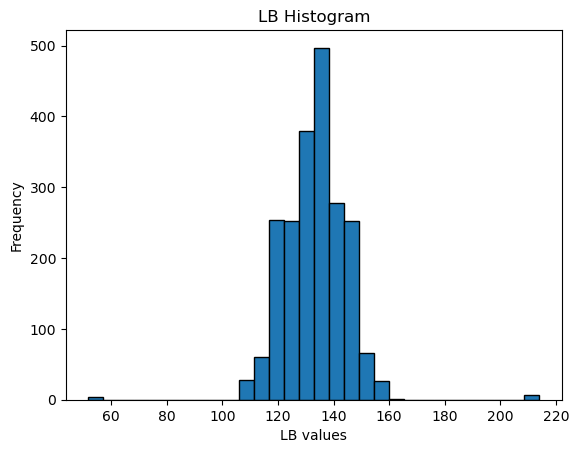

In [25]:
# 3) Data Visualization
import matplotlib.pyplot as plt
plt.hist(df["LB"],bins=30,edgecolor= "black")
plt.title("LB Histogram")
plt.xlabel("LB values")
plt.ylabel("Frequency")
plt.show()
# Histograms denote distribution and outliers for numerical columns.It is showing normal distribution.

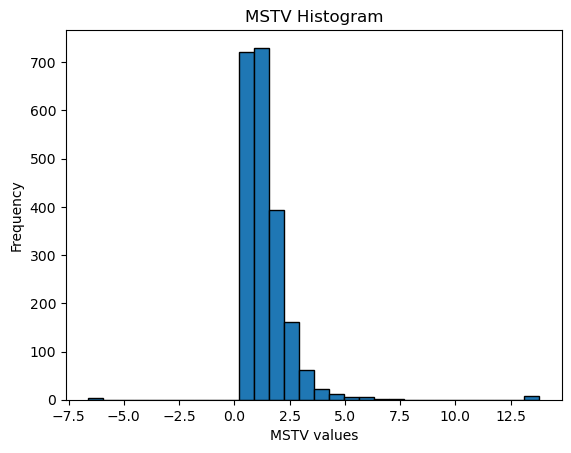

In [41]:
import matplotlib.pyplot as plt
plt.hist(df["MSTV"],bins=30,edgecolor= "black")
plt.title("MSTV Histogram")
plt.xlabel("MSTV values")
plt.ylabel("Frequency")
plt.show()
# It shows the tail towards right.Slightly positively skewed.

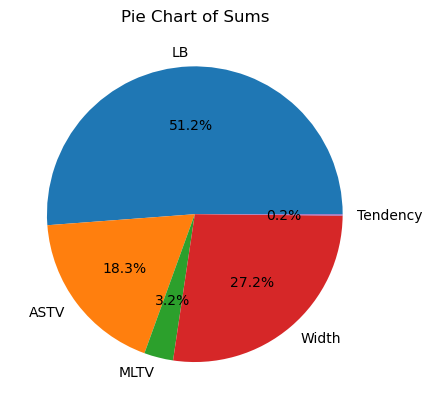

In [65]:
col = ["LB","ASTV","MLTV","Width","Tendency"]
sums = df[col].sum()
plt.pie(sums,labels=sums.index,autopct="%1.1f%%")
plt.title("Pie Chart of Sums")
plt.show()
#This pie chart shows the sum of the columns mentioned in the col.So most of the higher values belong to LB

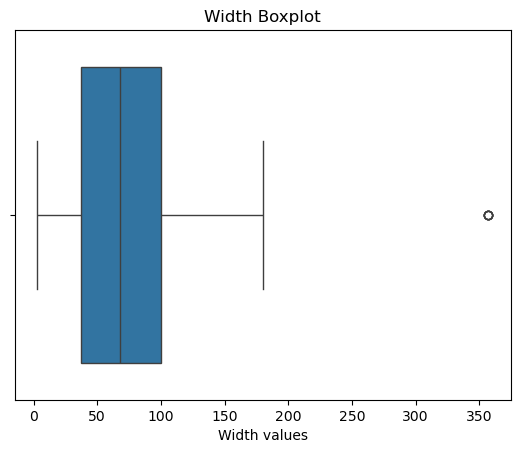

In [66]:
import seaborn as sns
sns.boxplot(x=df["Width"],orient="h")
plt.title("Width Boxplot")
plt.xlabel("Width values")
plt.show()
# This is boxplot for Width column.It has single outlier and it ranges from 0 to around 200.

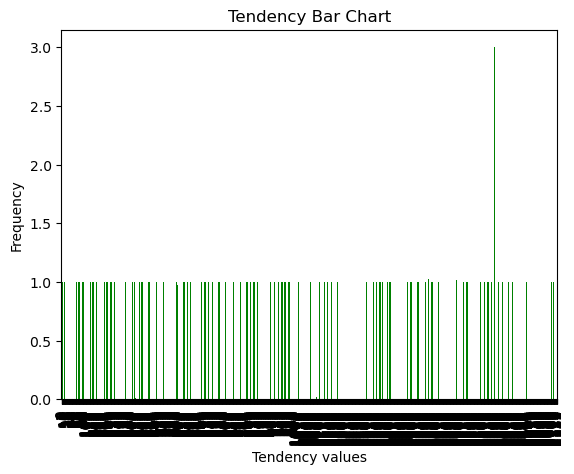

In [67]:
df["Tendency"].plot(kind="bar",color="green")
plt.title("Tendency Bar Chart")
plt.xlabel("Tendency values")
plt.ylabel("Frequency")
plt.show()
# There is no categorial value here. Hence bar chart is of no use.

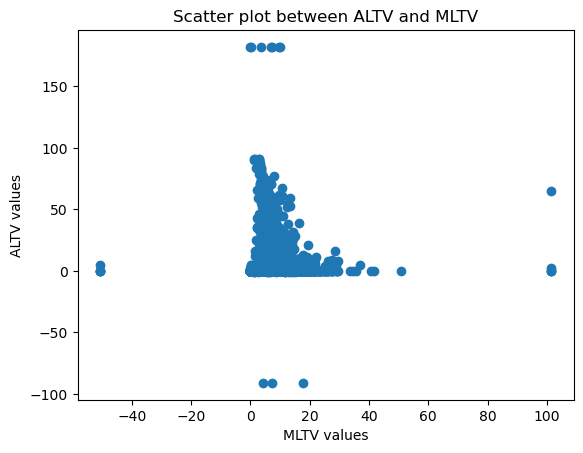

In [71]:
plt.scatter(df["MLTV"],df["ALTV"])
plt.title("Scatter plot between ALTV and MLTV")
plt.xlabel("MLTV values")
plt.ylabel("ALTV values")
plt.show()
#It shows that most of the points are centered in middle. That means very few outliers exists. And they are not that related as no correlation is shown.

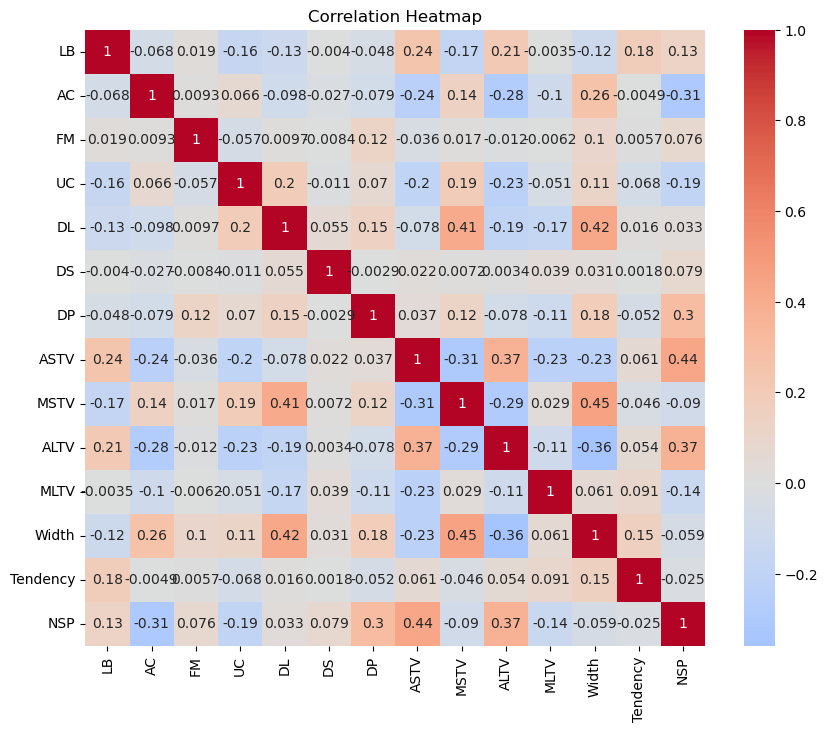

In [80]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()
# Here we can see that no column has dark red color except diagonal. It indicates all these values are independent in nature.

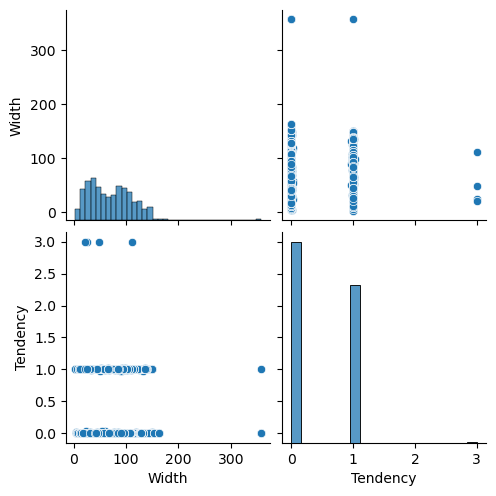

In [86]:
sns.pairplot(df[["Width","Tendency"]])
plt.show()
#As the data are not related, we get grouped data.

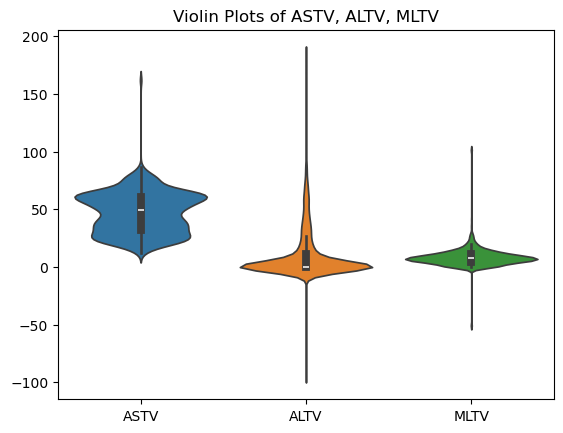

In [90]:
sns.violinplot(data=df[["ASTV", "ALTV", "MLTV"]])
plt.title("Violin Plots of ASTV, ALTV, MLTV")
plt.show()
# This shows violin plot for three columns.It shows boxplot in middle as well as the density and spread of data.

In [91]:
# 4) Pattern Recognition and Insights
# Here we cannot find any pattern or trend as this is not a temporal data.
# Also the data shows no correlation and hence no implications can be derived.

In [ ]:
# 5) Conclusion
# 1) The data in this dataset is all numeric and all the columns are not highly dependent on each other.
# 2) All the values in the dataset should be positive.
# 3) For LB,AC,FM,UC,DL,DS,DP columns, they have a normal distibution after handling outliers. It indicates that most of the patients have normal rates for these values.
# 4) For ASTV,ALTV,MLTV,Width and tendency columns, it shows variation. This indicates that the patients show some abnormal values for these medical values.
# 5) So overall, this data shows patients data of cardiographic reports and through outlier identification we can find reason why is it occuring and how much risk exists.